In [1]:
!pip install scanpy anndata pooch leidenalg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 100.2 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take in

In [2]:
from __future__ import annotations
import anndata as ad
import pooch
import scanpy as sc

sc.settings.set_figure_params(dpi=50, facecolor="white")

# Load data
EXAMPLE_DATA = pooch.create(
    path=pooch.os_cache("scverse_tutorials"),
    base_url="doi:10.6084/m9.figshare.22716739.v1/",
)
EXAMPLE_DATA.load_registry_from_doi()

samples = {
    "s1d1": "s1d1_filtered_feature_bc_matrix.h5",
    "s1d3": "s1d3_filtered_feature_bc_matrix.h5",
}
adatas = {}

for sample_id, filename in samples.items():
    path = EXAMPLE_DATA.fetch(filename)
    sample_adata = sc.read_10x_h5(path)
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata

adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()
print(adata.obs["sample"].value_counts())
print(adata)

/tmp/ipykernel_3519/2448543169.py:6: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=50, facecolor="white")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


sample
s1d1    8785
s1d3    8340
Name: count, dtype: int64
AnnData object with n_obs × n_vars = 17125 × 36601
    obs: 'sample'


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


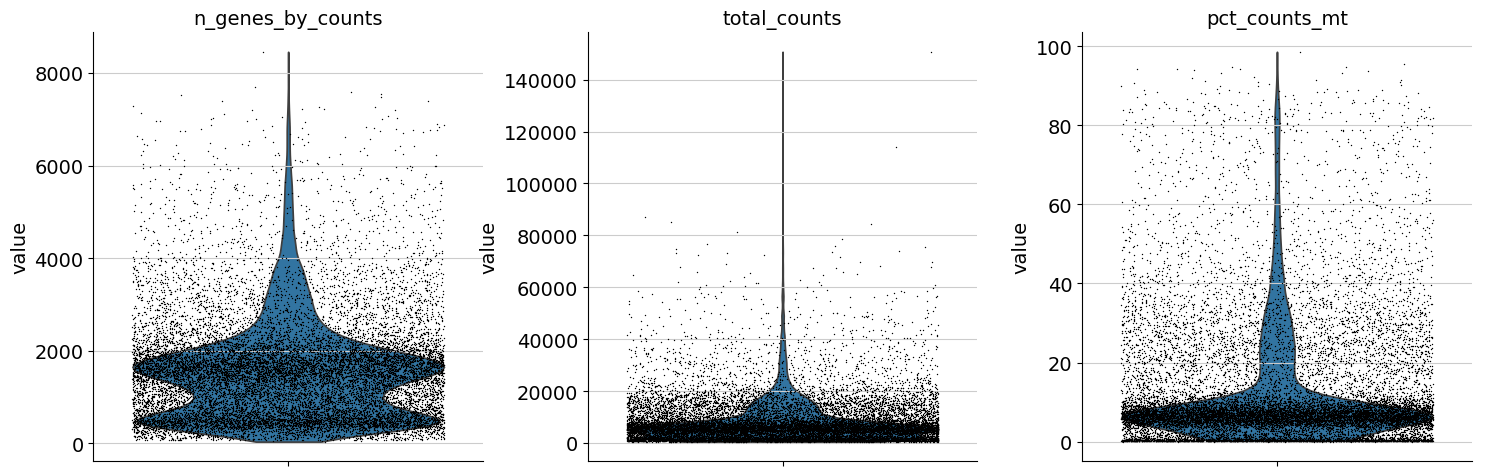

In [3]:
# Define gene categories
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

# Calculate QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt", "ribo", "hb"],
    inplace=True,
    log1p=True
)

# Plot QC metrics
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

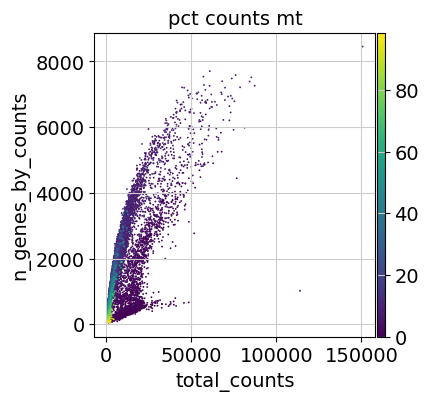

After filtering: 17041 cells, 23427 genes


In [4]:
# Scatter plot
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

# Filter cells and genes
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

print(f"After filtering: {adata.n_obs} cells, {adata.n_vars} genes")

In [5]:
# Doublet detection with Scrublet
sc.pp.scrublet(adata, batch_key="sample")

print("Doublet detection complete!")
print(adata.obs["predicted_doublet"].value_counts())

Doublet detection complete!
predicted_doublet
False    16828
True       213
Name: count, dtype: int64


In [6]:
# Save raw counts
adata.layers["counts"] = adata.X.copy()

# Normalize to median total counts
sc.pp.normalize_total(adata)

# Log transform
sc.pp.log1p(adata)

print("Normalization complete!")
print(adata)

Normalization complete!
AnnData object with n_obs × n_vars = 17041 × 23427
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet', 'log1p'
    layers: 'counts'


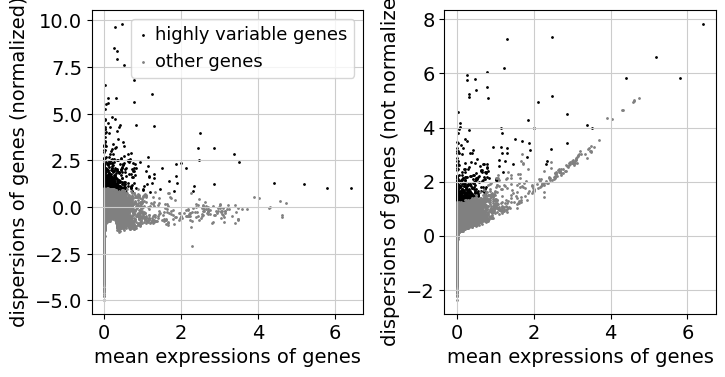

Highly variable genes: 2000


In [7]:
# Find highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")

# Plot highly variable genes
sc.pl.highly_variable_genes(adata)

print(f"Highly variable genes: {adata.var.highly_variable.sum()}")

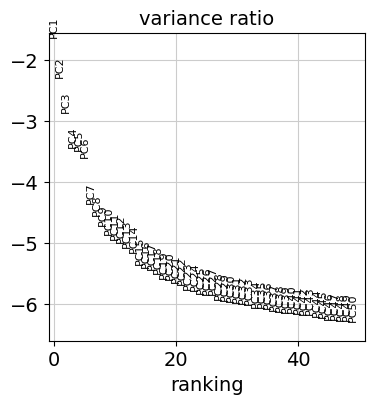

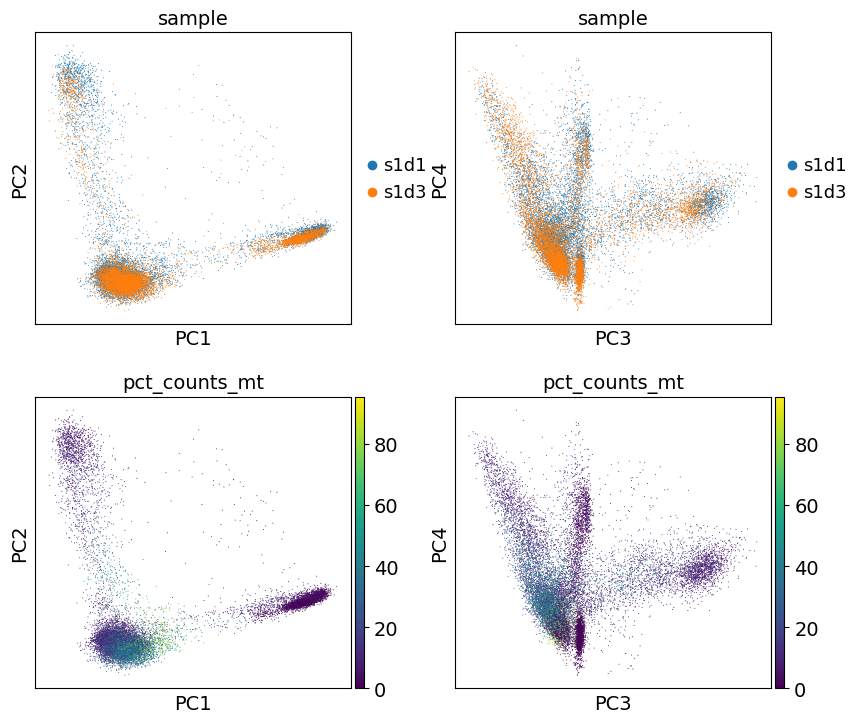

In [8]:
# Run PCA
sc.tl.pca(adata)

# Plot PCA variance ratio
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

# Plot PCA colored by sample and QC metrics
sc.pl.pca(
    adata,
    color=["sample", "sample", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

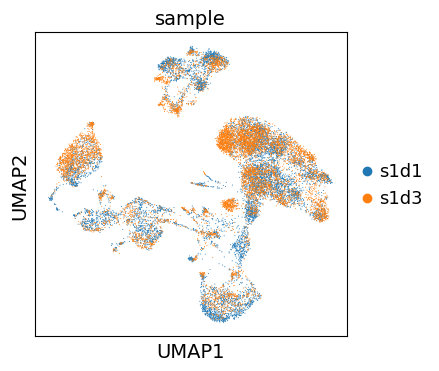

In [9]:
# Compute neighborhood graph
sc.pp.neighbors(adata)

# Compute UMAP
sc.tl.umap(adata)

# Plot UMAP colored by sample
sc.pl.umap(
    adata,
    color="sample",
    size=2,
)

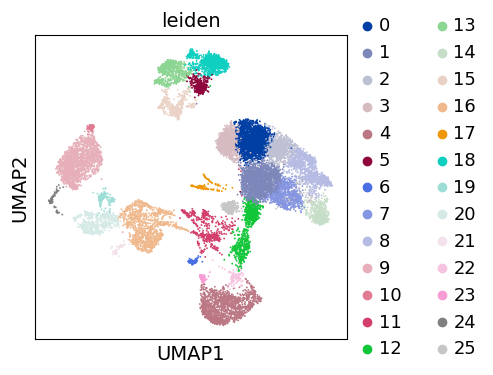

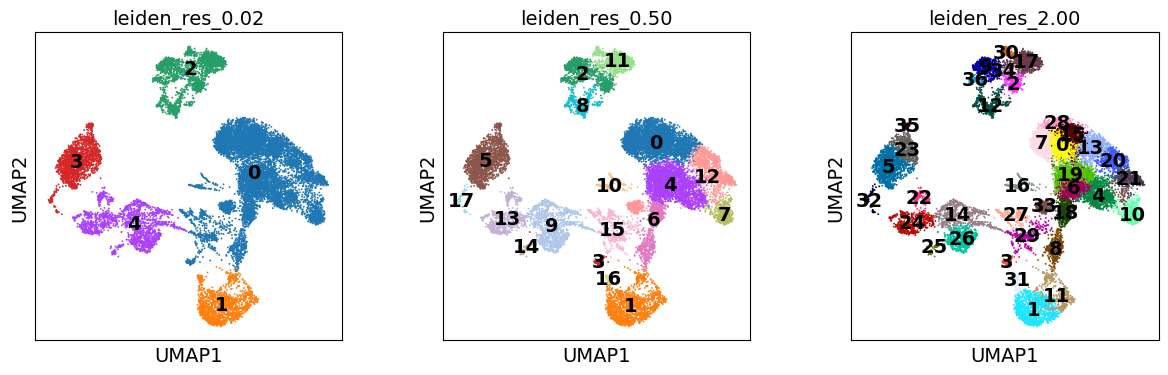

In [10]:
# Basic Leiden clustering
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)
sc.pl.umap(adata, color=["leiden"])

# Multiple resolutions
for res in [0.02, 0.5, 2.0]:
    sc.tl.leiden(
        adata,
        key_added=f"leiden_res_{res:4.2f}",
        resolution=res,
        flavor="igraph"
    )

# Plot all resolutions
sc.pl.umap(
    adata,
    color=["leiden_res_0.02", "leiden_res_0.50", "leiden_res_2.00"],
    legend_loc="on data",
)

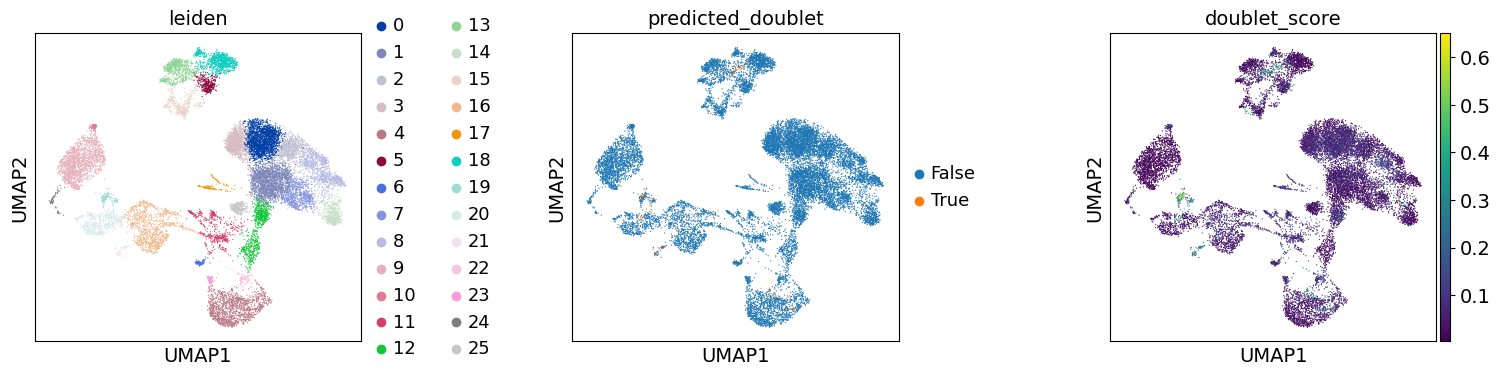

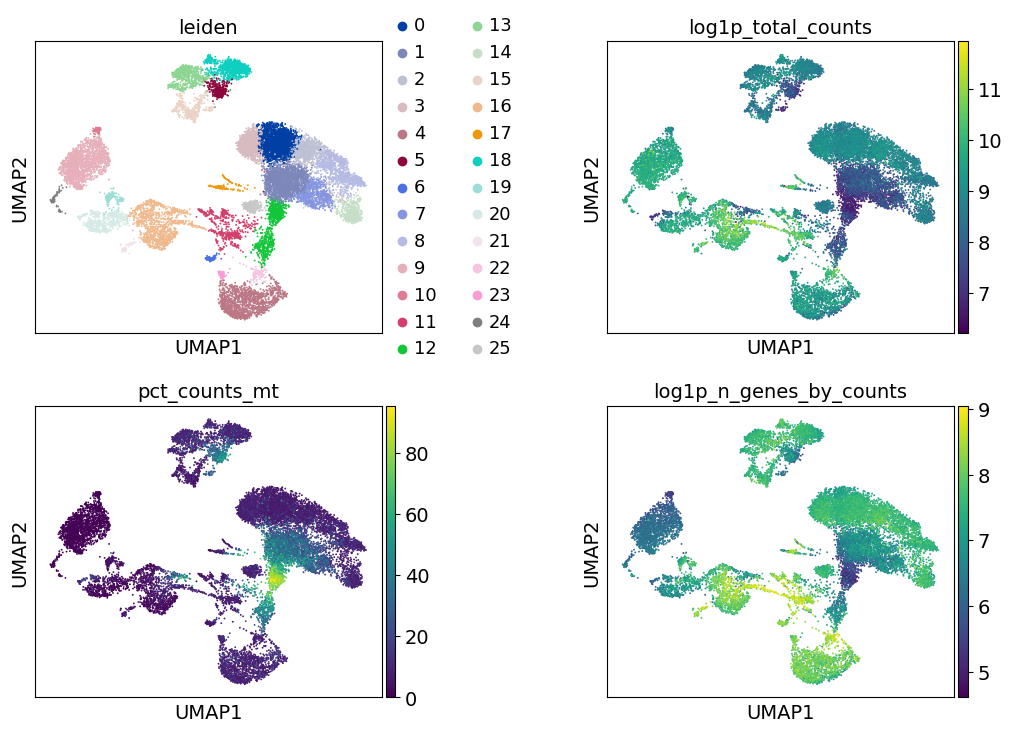

In [11]:
# Visualize doublets and QC on UMAP
sc.pl.umap(
    adata,
    color=["leiden", "predicted_doublet", "doublet_score"],
    wspace=0.5,
    size=3,
)

sc.pl.umap(
    adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)

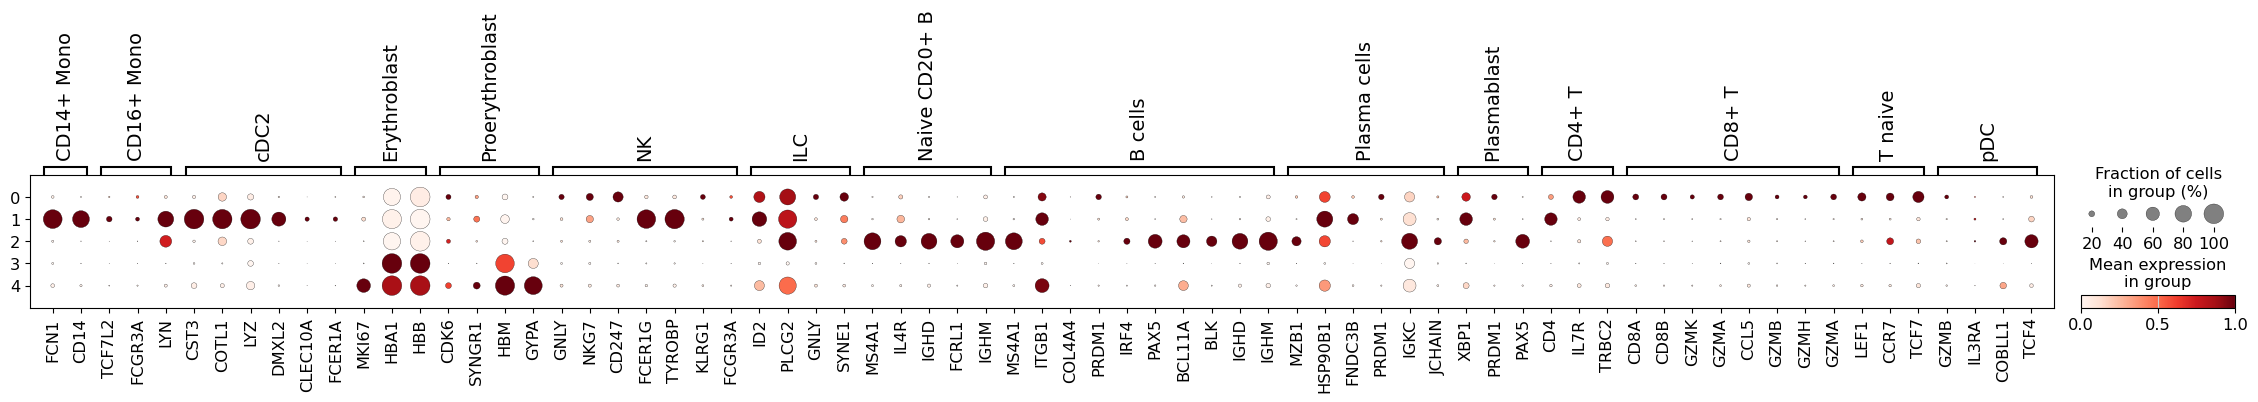

In [12]:
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    "Erythroblast": ["MKI67", "HBA1", "HBB"],
    "Proerythroblast": ["CDK6", "SYNGR1", "HBM", "GYPA"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    "B cells": ["MS4A1", "ITGB1", "COL4A4", "PRDM1", "IRF4", "PAX5", "BCL11A", "BLK", "IGHD", "IGHM"],
    "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
    "Plasmablast": ["XBP1", "PRDM1", "PAX5"],
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
}

sc.pl.dotplot(adata, marker_genes, groupby="leiden_res_0.02", standard_scale="var")

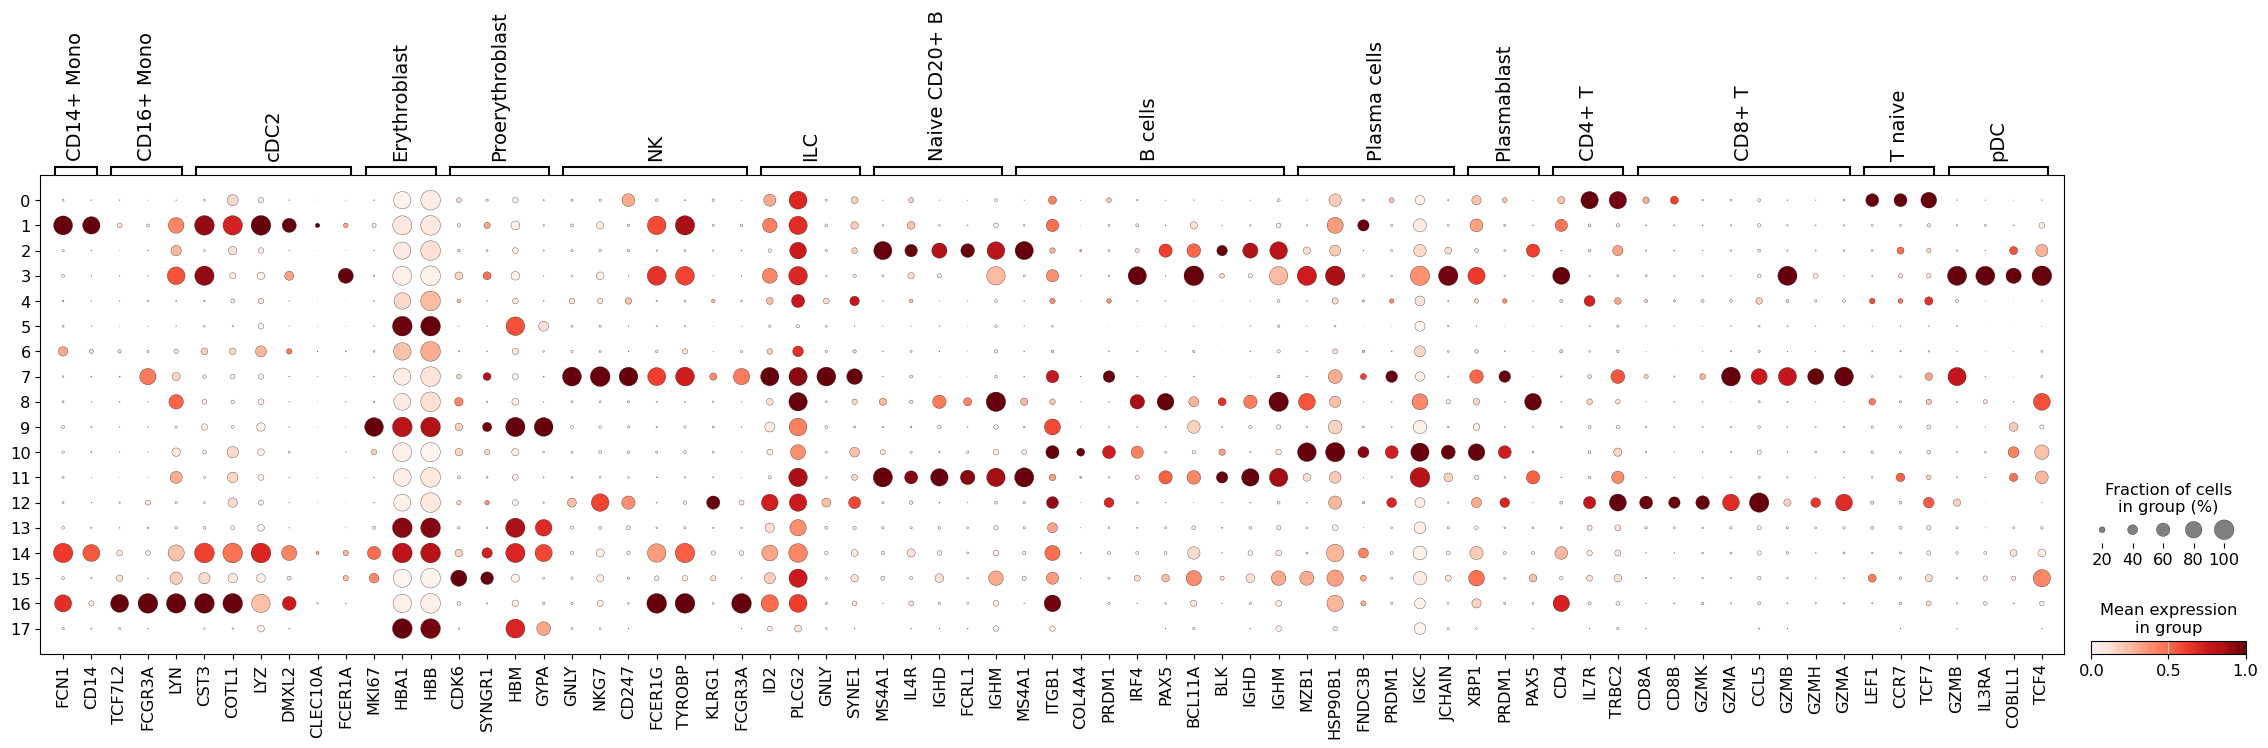

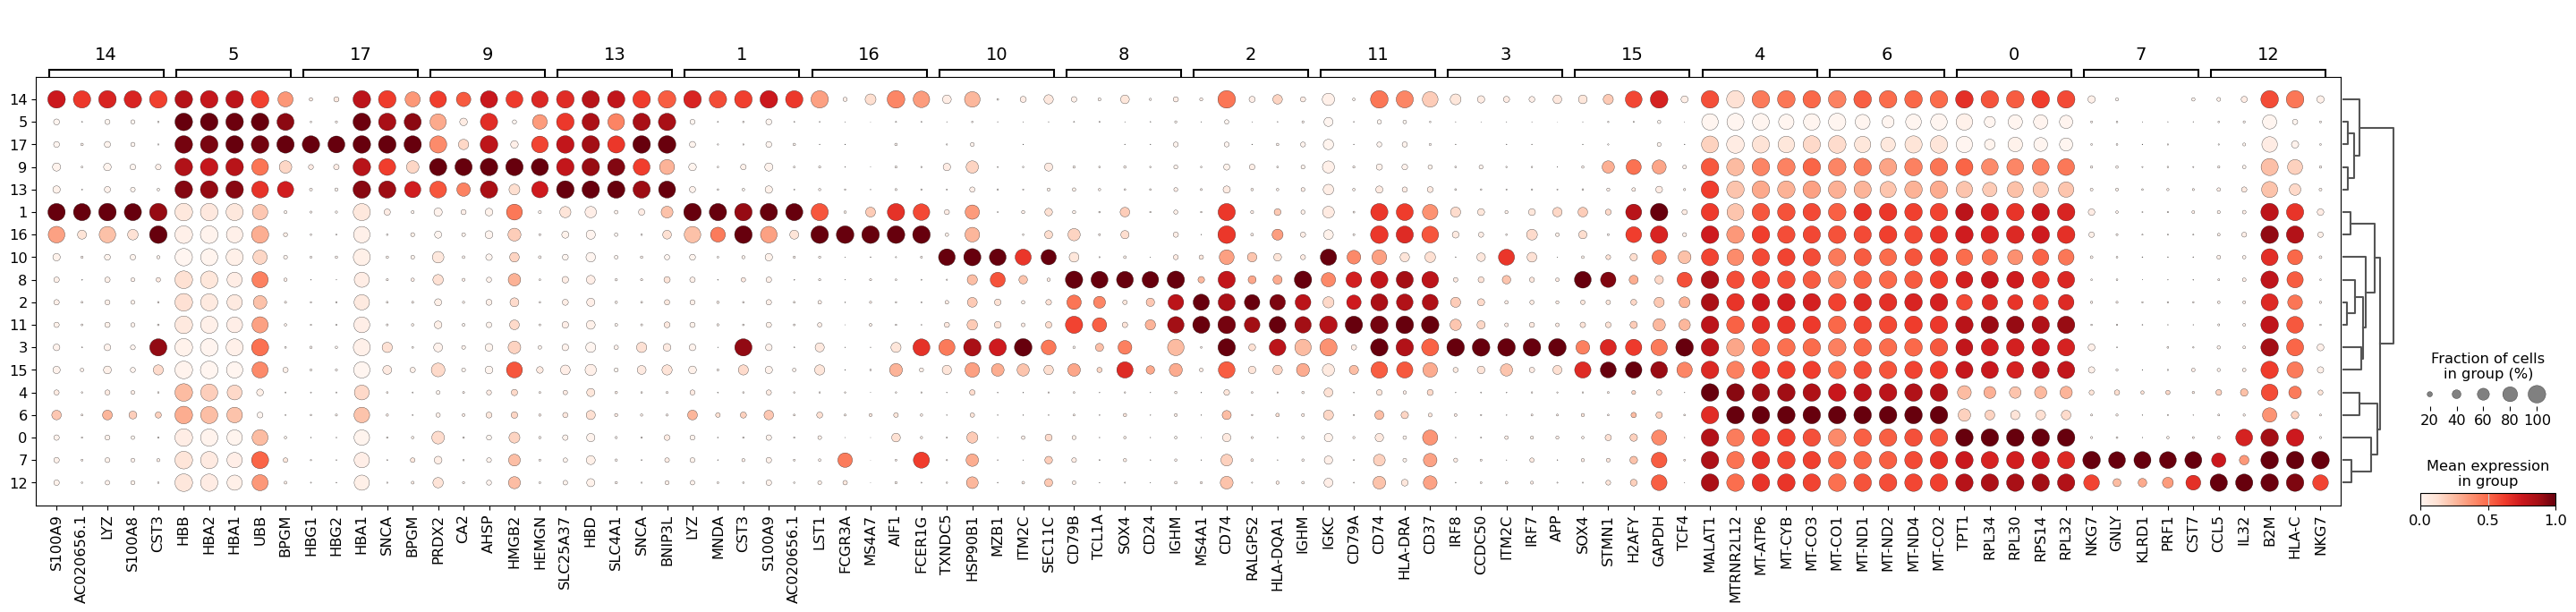

In [13]:
# Annotate cell types
adata.obs["cell_type_lvl1"] = adata.obs["leiden_res_0.02"].map(
    {
        "0": "Lymphocytes",
        "1": "Monocytes",
        "2": "Erythroid",
        "3": "B Cells",
    }
)

# Dotplot at medium resolution
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res_0.50", standard_scale="var")

# Differential expression
sc.tl.rank_genes_groups(adata, groupby="leiden_res_0.50", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby="leiden_res_0.50",
    standard_scale="var",
    n_genes=5
)

Top NK cell marker genes: ['NKG7', 'GNLY', 'KLRD1', 'PRF1', 'CST7']


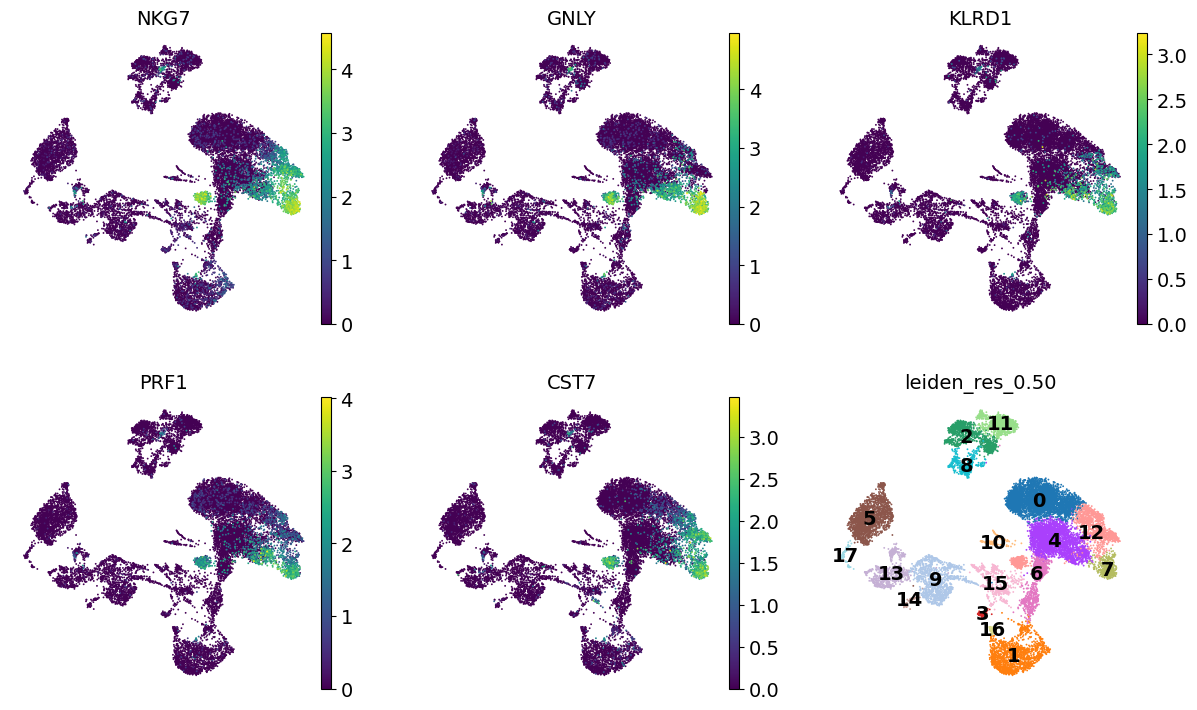

Analysis complete! AnnData saved!
AnnData object with n_obs × n_vars = 17041 × 23427
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'leiden_res_0.02', 'leiden_res_0.50', 'leiden_res_2.00', 'cell_type_lvl1'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'sample_colors', 'neighbors', 'umap', '

In [14]:
# Get top genes for cluster 7 (NK cells)
dc_cluster_genes = sc.get.rank_genes_groups_df(adata, group="7").head(5)["names"]
print("Top NK cell marker genes:", list(dc_cluster_genes))

# Visualize on UMAP
sc.pl.umap(
    adata,
    color=[*dc_cluster_genes, "leiden_res_0.50"],
    legend_loc="on data",
    frameon=False,
    ncols=3,
)

# Save the final AnnData object
adata.write_h5ad("scrnaseq_processed.h5ad")
print("Analysis complete! AnnData saved!")
print(adata)

In [16]:
# Download the processed data file
from google.colab import files
files.download("scrnaseq_processed.h5ad")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>